In [6]:
import math
import qutip as qt
from qutip import *
from qutip_qip.operations import ry, rz, rx
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline
import matplotlib.animation as animation
from mpl_toolkits.mplot3d import Axes3D
import pylab as plab
from scipy.optimize import minimize
from scipy.stats import unitary_group
import itertools
%matplotlib inline

In [7]:
GHz = 1
MHz = 1e-3
kHz = 1e-6
Hz = 1e-9

Nc = 1500
a = qt.tensor(qt.destroy(Nc), qt.qeye(2))
sigz = qt.tensor(qt.qeye(Nc), qt.sigmaz())
sigp = qt.tensor(qt.qeye(Nc), qt.sigmam())
sigm = qt.tensor(qt.qeye(Nc), qt.sigmap())
sigx = sigp + sigm
sigy = -1j*(sigm - sigp)

## Free Hamiltonian

$$ H = -\frac{\chi}{2}\hat{a}^\dagger \hat{a}\hat{\sigma}_z - \frac{\chi'}{2}\hat{a}^\dagger\hat{a}^\dagger\hat{a}\hat{a}\hat{\sigma}_z - K_s\hat{a}^\dagger\hat{a}^\dagger\hat{a}\hat{a} $$

Note that $\hat{n}^2 = \hat{n} + \hat{a}^\dagger\hat{a}^\dagger\hat{a}\hat{a}$ (i.e.,   $\hat{n}^2 \equiv\hat{a}^\dagger\hat{a}^\dagger\hat{a}\hat{a}$),  since the $\hat{n}$ term will be combined with the other Hamiltonian terms. Hence the Hamiltonian above describes 
$$ H \equiv \frac{\chi}{2}\hat{n}\hat{\sigma}_z - \frac{\chi'}{2}\hat{n}^2\hat{\sigma}_z- K_s\hat{n}^2$$ 
where $\chi$ is the first-order Dispersive shift, $\chi'$ is the second-order correction to the dispersive shift and $K_s$ is the Kerr self nonlinearity.


## Drive Hamiltonian
$$ H_d = C_I(t)[\hat{a}+ \hat{a}^\dagger] - i C_Q(t)[\hat{a}+ \hat{a}^\dagger] + q_I(t)\hat{\sigma}_x + q_Q(t)\hat{\sigma}_y$$

where $C_{I,Q}$ are the cavity drives in the $I-Q$ quadrature while $q_{I,Q}$ are the qubit drives in the $I-Q$ quadrature.

## Arbitrary unitary decomposition

Define the Echoed Conditional Displacement (ECD) gate as 

$$\text{ECD}(\beta) = D(\beta/2)|e\rangle |g\rangle + D(-\beta/2)|g\rangle |e\rangle = \sigma_xD(\beta\sigma_z/2)$$

where $\beta\in \mathbb{C}$ and $D(\alpha) = e^{\alpha \hat{a}^\dagger- \alpha^*\hat{a}}$.

Define arbitrary rotation as 
$$ 
R_\varphi(\theta) = \exp{\left[-i\frac{\theta}{2}(\sigma_x\cos(\varphi)+ \sigma_y\sin(\varphi))\right]} = \cos(\theta/2)I - i[\sigma_x\cos(\varphi)+ \sigma_y\sin(\varphi)]\sin(\theta/2).$$
 
where the right hand side is by the Euler identity since $[\sigma_x\cos(\varphi)+ \sigma_y\sin(\varphi)]^2=1$. i.e  Rotation by $\theta$ about the axis $(\cos\varphi, \sin\varphi, 0)$ in the $XY-$plane.

The ECD and Rotation gate form a universal gateset as seen in https://journals.aps.org/rmp/pdf/10.1103/RevModPhys.77.513




From above reference, the an ECD($\beta$) is decomposed into (hardware) gates (of 4 Displacements and one $\pi$ gate on the Transmon) such that 
$$\text{ECD}(\beta) \approx \text{ECD}(2i\alpha\sin(\chi T/2))$$
where $\chi$ is the dispersive coupling, $T$ is the total gate duration. Hence, the displacement in the cavity has a radius $\chi T \alpha$. Hence, from dimension analysis,  $\beta\sim \mu Hz $ since $\chi\sim KHz$, and $T \sim ns$. 

Recall that $\langle \beta |\hat{N}|\beta\rangle = \beta^2$, where $\hat{N} = \hat{a}^\dagger\hat{a}$. Hence, for the state $|\beta\rangle$ in the cavity the average number of photons is $|\beta|^2$ .i.e. If the number of photons feasible on a hardware is $\sim 30$, then the expected displacement distance is $\sim 5.477$.


The cost/fidelity function for gate ECD is defined as 

$$ \mathcal{F}= 1-\left|\frac{1}{\text{Tr}(P)}\text{Tr}(PU^\dagger_{\text{target}}U_{\text{ECD}})\right|^2$$
where $P$ is the projection unto the Hilbert space. $U_{ECD}$ is defined as follows

$$ U_{\text{ECD}} = D(\beta_{L+1})R_{\varphi_{L+1}}(\theta_{L+1})\cdot\text{ECD}(\beta_L)R_{\varphi_L}(\theta_L)\cdots \text{ECD}(\beta_1)R_{\varphi_1}(\theta_1).$$


Note the $P$ is the identity operator in this case since we want to consider the space of dimension $N_{\text{trunc}}$. 

To define the gradient for the cost function $\mathcal{F}$, apply the Parameter-shift Rule (as in https://pennylane.ai/qml/glossary/parameter_shift):
$$ \nabla_{\gamma_i} \mathcal{F}(\vec{\gamma}) = \frac{\mathcal{F}(\gamma_i + \varepsilon) - \mathcal{F}(\gamma_i - \varepsilon)}{2\sinh(\varepsilon)}$$

where $\vec{\gamma} = (\vec{\beta}, \vec{\varphi}, \vec{\theta})$ for arbitrary  $\gamma_i$ and any $\varepsilon>0$.

Theoretically, the expected number of blocks to reach 'good' fidelity = $((2N_{trunc})^2-1)/4 = N_{trunc}^2- 1/4 \sim \mathcal{O}(N_{trunc}^2)$.

In [101]:
# # --- Global settings 

# # file_directory = r'/home/roytanay/Sideband'

# default_dtype = torch.float32
# complex_dtype = torch.complex64
# numpy_tolerance = 1e-6
# MIXED_PRECISION = True

# # ---

# torch.set_default_dtype(default_dtype)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
# # device = torch.device("cpu")
# device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
# # device = torch.device("cpu")

print('--- Notes ---')
print('You must use a CUDA-enabled GPU to run this notebook.')
print('--- Device ---')
print('Device (GPU) count:', torch.cuda.device_count())
if torch.cuda.is_available():
    print('CUDA available. Current device:', torch.cuda.get_device_name(torch.cuda.current_device()))
else:
    print('No CUDA device available; skipping device name query.')

print('Using device:', device)

print('Mixed precision via autocast available for CUDA:', torch.amp.autocast_mode.is_autocast_available('cuda'))

# print('--- Datatype ---')
# print(f"Default dtype: {torch.get_default_dtype()}")
# print('Default complex dtype:', complex_dtype)
# print('Using mixed precision (bfloat16):', MIXED_PRECISION)

--- Notes ---
You must use a CUDA-enabled GPU to run this notebook.
--- Device ---
Device (GPU) count: 0
No CUDA device available; skipping device name query.
Using device: cpu
Mixed precision via autocast available for CUDA: True


In [8]:
def ECD_Compile(betas_real,betas_imag , phis, thetas, Unitary, N_trunc, tol, Add_block = False, Disp = False):
    def ECD(beta_real, beta_imag, N_trunc):    
        return tensor(sigmap(), displace(N_trunc, (beta_real+ 1j*beta_imag)/2)) + tensor(sigmam(), displace(N_trunc, -(beta_real+ 1j*beta_imag)/2))
    
    # def Rot(phi, theta, N_trunc):
    #     return tensor(rz(phi) * rx(theta) * rz(-phi), qeye(N_trunc))
    
    def Rot(phi, theta, N_trunc):
        sx = qt.tensor(qt.sigmax(), qt.identity(N_trunc))
        sy = qt.tensor(qt.sigmay(), qt.identity(N_trunc))
        idty = qt.tensor(qt.identity(2), qt.identity(N_trunc))
        if theta == 0:
            return idty
        else:          
            return ((np.cos(theta/2.0))*idty - 1j * ((np.cos(phi) * sx) + (np.sin(phi) * sy)) * np.sin(theta/2.0))
       
        # return (-1j*(theta/2.0)*(np.cos(phi)*self.sx + np.sin(phi)*self.sy)).expm()        
        # return np.cos(theta / 2.0) * idty - 1j * (
        #     np.cos(phi) * sx + np.sin(phi) * sy
        # ) * np.sin(theta / 2.0)
    
    
    # One ECD Block
    def U_block_ECD(beta_real, beta_imag, phi, theta, N_trunc):
        return ECD(beta_real, beta_imag,  N_trunc) * Rot(phi, theta, N_trunc) 

    # def U_block_ECD2(beta_real, beta_imag, phi, theta, N_trunc):
    #     return ECD(beta_real, beta_imag,  N_trunc) * Rot(phi, theta, N_trunc)* ECD(beta_real, beta_imag,  N_trunc).dag()
    
    # Sequence of ECD blocks
    def U_circuit_ECD(betas_real, betas_imag, phis, thetas, N_trunc):
        U = qt.tensor(qt.identity(2), qt.identity(N_trunc))
        for beta_real, beta_imag, phi, theta in zip(betas_real[:-1], betas_imag[:-1], phis[:-1], thetas[:-1]): # [:-1] removes the last element in the list since they are  Disp. and rotation parameter
            U = U_block_ECD(beta_real, beta_imag, phi, theta, N_trunc) * U
            # U = U_block_ECD2(beta_real, beta_imag, phi, theta, N_trunc) * U
        
        if Add_block == False:
            return U
        else:
            return qt.tensor(qt.identity(2), displace(N_trunc, (betas_real[-1]+ 1j*betas_imag[-1])/2)) * Rot(phis[-1], thetas[-1], N_trunc) * U
    
    def Unitary_cost(Oper1, Oper2):
              # tracedist(Oper1, Oper2)
            # cost = 1- (abs((Oper1.dag()*Oper2).tr()/Oper1.shape[0]))**2

            # U3 = Oper1-Oper2
            # cost = np.sqrt((U3.dag()*U3).tr())        

            U1 = Qobj(Oper1[0:N_trunc, 0:N_trunc]- Oper2[0:N_trunc, 0:N_trunc], dims = [N_trunc, N_trunc])
            U2 = Qobj(Oper1[N_trunc:2*N_trunc, N_trunc:2*N_trunc]- Oper2[N_trunc:2*N_trunc, N_trunc:2*N_trunc],dims = [N_trunc, N_trunc]) 
            U = U1-U2
            cost = np.sqrt(np.abs((U1.dag()*U1).tr()))   
            # U1 = Qobj(Oper1[0:N_trunc, 0:N_trunc], dims = [N_trunc, N_trunc])
            # U2 = Qobj(Oper2[0:N_trunc, 0:N_trunc], dims = [N_trunc, N_trunc])
            # U3 = Qobj(Oper1[N_trunc:2*N_trunc, N_trunc:2*N_trunc], dims = [N_trunc, N_trunc]) 
            # U4 = Qobj(Oper2[N_trunc:2*N_trunc, N_trunc:2*N_trunc], dims = [N_trunc, N_trunc]) 
            # # U = U1-U2
            # U = U1.dag()*U2
            # Uval = np.sqrt(U.shape[0] - np.abs(U.tr()))
            return cost
        
    
    opt_process = {}  
    def my_callback(result):
        """
        A callback function to monitor optimization progress.
        """
        val = Error_func(result, Unitary, N_trunc)
        opt_process[val]= result
    
    # Trace norm
    def Error_func(params, Unitary, N_trunc):
        '''params=[betas, varphis, thetas] - hence 3l sized list '''
        ''''  args = (Unitary)'''
        
        r = int(len(params)/4)
        U = U_circuit_ECD(params[0:r], params[r:2*r], params[2*r:3*r], params[3*r:4*r], N_trunc)
        return Unitary_cost(Unitary, U)

    def grad(ini_params, Unitary, N_trunc):

        deriv = []  
        epsilon = 5e-10
        for i in range(len(ini_params)):
            new_params_plus = [ele for ele in ini_params]
            new_params_minus = [ele for ele in ini_params] 
            new_params_plus[i] = ini_params[i] + epsilon
            new_params_minus[i] = ini_params[i] - epsilon
            partial_deriv_i = (Error_func(new_params_plus, Unitary, N_trunc) 
                               - Error_func(new_params_minus, Unitary, N_trunc))/(2*np.sinh(epsilon))
            deriv.append(partial_deriv_i)  
        return deriv

    def grad2(ini_params, Unitary, N_trunc):

        deriv = []
        h = 1e-8
        for i in range(len(ini_params)):            
            params_plus = [ele for ele in ini_params]
            params_plus[i] = params_plus[i] + h
            partial_deriv_i = (Error_func(params_plus, Unitary, N_trunc) 
                               - Error_func(ini_params, Unitary, N_trunc))/h
            deriv.append(partial_deriv_i)  
        return deriv

    if Unitary.isunitary == False:
        raise ValueError("Provided operator is non-unitary.")
    

    
    if Add_block == True:
        Extra_block = 1
    else:
        Extra_block = 0
        
    
    ini_params = np.concatenate((betas_real,np.concatenate((betas_imag, np.concatenate((phis, thetas))))))
    print('\n' + '*'* 20 + f' Optimizing Parameters for {int(len(ini_params)/4 - 1 + Extra_block)} blocks ' 
          + f'including {Extra_block} Disp_Rot block ' + '*'* 20, '\n\n' )
    res = minimize(Error_func, ini_params, args = (Unitary, N_trunc), method = 'L-BFGS-B',  jac = grad,
                   tol = tol, callback = my_callback)    # jac = grad,, options={'gtol': 1e-8, 'maxiter':1000}

    
    opt_arg = res.x
    opt_val = res.fun   
    opt_hist = list(opt_process.keys())


    k = int(len(opt_arg)/4)
    out_dict = {'Infidelity': opt_val, 'Betas_real': opt_arg[0:k], 'Betas_imag': opt_arg[k:2*k], 
                'Phis': opt_arg[2*k:3*k], 'Thetas': opt_arg[3*k:4*k]}

    # Plot optimization History
    if Disp==True:
        plt.plot(range(len(opt_hist)), opt_hist, marker='o', linestyle='dashed')
        plt.axhline(y = opt_val, color = 'r', linestyle='--', label= f'y = {opt_val:.3g}')
        plt.title(f'Optimization History for {int(len(ini_params)/4)} blocks with {Extra_block} Disp_Rot block.')
        plt.grid(which = 'both', axis='both')
        plt.ylabel('Infidelity')
        plt.xlabel('Number of shots')
        plt.yscale('log')
        plt.legend()
        plt.show()

        Mat = U_circuit_ECD(opt_arg[0:k],opt_arg[k:2*k], opt_arg[2*k:3*k], opt_arg[3*k:4*k], N_trunc)
        print(Mat)
    return out_dict




In [115]:
# Define cavity unitary
N_trunc = 2
mat = np.zeros((N_trunc, N_trunc), dtype = np.complex64)
# mat[0,1]= 1
# mat[1,0] = 1
for k in range(N_trunc):
    mat[k,k] = np.exp(1j*np.pi*(k+1)/2)
    
cav_unitary = Qobj(mat, dims = [N_trunc, N_trunc])

# generate random cavity unitary
# cav_unitary = Qobj(unitary_group.rvs(N_trunc), dims = [N_trunc, N_trunc])   

# generate random Transmon unitary
# trans_unitary = Qobj(unitary_group.rvs(2), dims = [2, 2])   
trans_unitary = qt.qeye(2)

# Combined Transmon and cavity system
Unitary = qt.tensor(trans_unitary, cav_unitary)

In [116]:
# Parameters
np.random.seed(100)
length = 4

# ECD sequence length (+1 since an extra block is used for unconditional displacement + Rotation)
N_blocks = length +1 

betas_real= np.random.randn(N_blocks) 
betas_imag= np.random.randn(N_blocks)
phis =  np.random.randn(N_blocks)
thetas = 2*np.pi*np.random.randn(N_blocks)
tol = 1e-12


******************** Optimizing Parameters for 4 blocks including 0 Disp_Rot block ******************** 




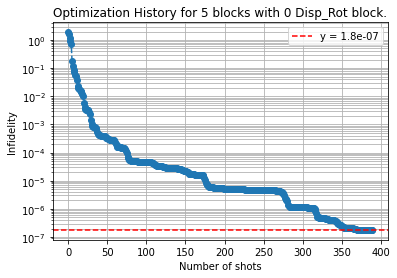

Quantum object: dims=[[2, 2], [2, 2]], shape=(4, 4), type='oper', dtype=Dense, isherm=False
Qobj data =
[[-1.39095872e-10+9.99999935e-01j  1.90570255e-08+1.25297206e-08j
   9.85774207e-05-1.04837055e-04j -3.22304922e-04-7.84555474e-05j]
 [-1.26371221e-08-1.92080727e-08j -9.99999836e-01+1.14478826e-10j
   3.71615089e-04-4.11645303e-04j  1.04837055e-04+9.85774206e-05j]
 [-1.04837055e-04+9.85774206e-05j -3.71615089e-04-4.11645303e-04j
  -9.99999836e-01-1.14478740e-10j -1.26371222e-08+1.92080728e-08j]
 [ 3.22304922e-04-7.84555474e-05j -9.85774207e-05-1.04837055e-04j
   1.90570256e-08-1.25297206e-08j -1.39095779e-10-9.99999935e-01j]]
CPU times: user 52.8 s, sys: 156 ms, total: 53 s
Wall time: 26.4 s


{'Infidelity': 1.796125545651379e-07,
 'Betas_real': array([-1.07314382, -0.6699521 ,  1.25475103, -3.08600162,  0.98132079]),
 'Betas_imag': array([ 0.7293184 ,  0.4543597 , -0.85217102, -0.58963555,  0.25500144]),
 'Phis': array([ 1.48297602,  3.77035243, -0.62893345, -0.6226856 ,  0.67272081]),
 'Thetas': array([-4.57472213, -1.92304527,  7.41420049,  1.10672799, -7.02660077])}

In [120]:
# Run optimization
%time ECD_Compile(betas_real, betas_imag, phis, thetas, Unitary, N_trunc, tol, Add_block = False, Disp=True)

In [118]:
# Unitary[N_trunc:2*N_trunc, N_trunc:2*N_trunc] qt.tr
Unitary

Quantum object: dims=[[2, 2], [2, 2]], shape=(4, 4), type='oper', dtype=Dense, isherm=False
Qobj data =
[[ 6.12323426e-17+1.00000000e+00j  0.00000000e+00+0.00000000e+00j
   0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j]
 [ 0.00000000e+00+0.00000000e+00j -1.00000000e+00+1.22464685e-16j
   0.00000000e+00+0.00000000e+00j -0.00000000e+00+0.00000000e+00j]
 [ 0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
   6.12323426e-17+1.00000000e+00j  0.00000000e+00+0.00000000e+00j]
 [ 0.00000000e+00+0.00000000e+00j -0.00000000e+00+0.00000000e+00j
   0.00000000e+00+0.00000000e+00j -1.00000000e+00+1.22464685e-16j]]

In [8]:
def infidelity_plots(Unitary, N_trunc, tol, block_sizes, Add_block = False, Disp= False):
    '''block_sizes = list of block sizes '''

    Infid_vs_blocks = []
    for N in block_sizes:
        np.random.seed(10)                     
        betas_real= np.random.randn(int(N)) 
        betas_imag= np.random.randn(int(N))
        phis = np.random.randn(int(N))
        thetas = 2*np.pi*np.random.randn(int(N))
        infidelity = ECD_Compile(betas_real, betas_imag, phis, thetas, Unitary, 
                                           N_trunc, tol, Add_block = Add_block,Disp= False)['Infidelity']
        Infid_vs_blocks.append(infidelity)
        
        
    
    #  Plot of infidelity vs No. of blocks
    plt.plot(block_sizes, Infid_vs_blocks, marker='o', linestyle='dashed')
    # plt.scatter(block_sizes, Infid_vs_blocks, color = 'r', linestyle='--') #  , label= f'y = {k:.3g}'
    plt.yscale('log')
    plt.xlabel('No. of blocks')    
    plt.title(f'Infidelity vs No. of blocks (Cavity_dim = {N_trunc})')
    plt.grid(which = 'both', axis='both')
    plt.ylabel('Infidelity')    
    # plt.legend()
    plt.show()



******************** Optimizing Parameters for 4 blocks including 0 Disp_Rot block ******************** 



******************** Optimizing Parameters for 5 blocks including 0 Disp_Rot block ******************** 



******************** Optimizing Parameters for 6 blocks including 0 Disp_Rot block ******************** 



******************** Optimizing Parameters for 7 blocks including 0 Disp_Rot block ******************** 



******************** Optimizing Parameters for 8 blocks including 0 Disp_Rot block ******************** 



******************** Optimizing Parameters for 9 blocks including 0 Disp_Rot block ******************** 




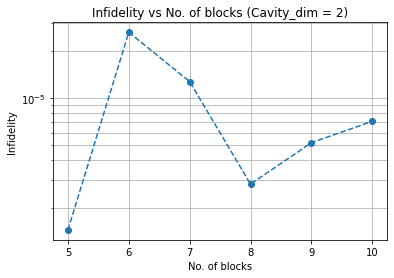

CPU times: user 5min 30s, sys: 599 ms, total: 5min 30s
Wall time: 2min 45s


In [130]:
N_trunc = 2

# generate random cavity unitary
cav_unitary = Qobj(unitary_group.rvs(N_trunc), dims = [N_trunc, N_trunc])  

Unitary2 = qt.tensor(qt.qeye(2), cav_unitary)   
min_size = 5
max_size = 10
block_sizes = range(min_size, max_size+1,1)
%time infidelity_plots(Unitary2, N_trunc, tol, block_sizes, Add_block = False, Disp = False)

## Disentangling Transmon from Cavity in ECD

In [128]:
# def ECD_Compile_Disentagled(betas_real,betas_imag , phis, thetas, rand_trans, rand_cav, N_trunc, tol, 
#                             Gate_Operation = False, Add_block = False):
#     def ECD(beta_real, beta_imag, N_trunc):    
#         return tensor(sigmap(), displace(N_trunc, (beta_real+ 1j*beta_imag)/2)) + tensor(sigmam(), displace(N_trunc, -(beta_real+ 1j*beta_imag)/2))
    
#     # def Rot(phi, theta, N_trunc):
#     #     return tensor(rz(phi) * rx(theta) * rz(-phi), qeye(N_trunc))
    
#     def Rot(phi, theta, N_trunc):
#         sx = qt.tensor(qt.sigmax(), qt.identity(N_trunc))
#         sy = qt.tensor(qt.sigmay(), qt.identity(N_trunc))
#         idty = qt.tensor(qt.identity(2), qt.identity(N_trunc))
#         if theta == 0:
#             return idty
#         else:          
#             return ((np.cos(theta/2.0))*idty - 1j * ((np.cos(phi) * sx) + (np.sin(phi) * sy)) * np.sin(theta/2.0))
       
#         # return (-1j*(theta/2.0)*(np.cos(phi)*self.sx + np.sin(phi)*self.sy)).expm()        
#         # return np.cos(theta / 2.0) * idty - 1j * (
#         #     np.cos(phi) * sx + np.sin(phi) * sy
#         # ) * np.sin(theta / 2.0)
    
    
#     # One ECD Block
#     def U_block_ECD(beta_real, beta_imag, phi, theta, N_trunc):
#         return ECD(beta_real, beta_imag,  N_trunc) * Rot(phi, theta, N_trunc)
    
#     # Sequence of ECD blocks
#     def U_circuit_ECD(betas_real, betas_imag, phis, thetas, N_trunc):
#         U = qt.tensor(qt.identity(2), qt.identity(N_trunc))
#         for beta_real, beta_imag, phi, theta in zip(betas_real[:-1], betas_imag[:-1], phis[:-1], thetas[:-1]): # [:-1] removes the last element in the list since they are  Disp. and rotation parameter
#             U = U_block_ECD(beta_real, beta_imag, phi, theta, N_trunc) * U
        
#         if Add_block == False:
#             return U
#         else:
#             return qt.tensor(qt.identity(2), displace(N_trunc, (betas_real[-1]+ 1j*betas_imag[-1])/2)) * Rot(phis[-1], thetas[-1], N_trunc) * U
            
#     def Unitary_cost(Oper1, Oper2):
#               # tracedist(Oper1, Oper1)
#             cost = 1- (abs((Oper1.dag()*Oper2).tr()/Oper1.shape[0]))**2
#             return cost 

#     def entangle_cost(state):
#         rho = ket2dm(state) 
#         red_mat = qt.ptrace(rho,[0])
#         return qt.entropy_vn(red_mat)
        
    
#     opt_process = {}  
#     def my_callback(result):
#         """
#         A callback function to monitor optimization progress.
#         """
#         ''' result - optimized argument
#         '''
#         val = Error_func(result, Unitary, N_trunc)
#         opt_process[val]= result

#     def my_callback2(result):
#         """
#         A callback function to monitor optimization progress.
#         """
#         ''' result - optimized argument
#         '''
#         val = Entangle_Error_func(result, ini_state, N_trunc)
#         opt_process[val]= result
    
#     # Trace norm
#     def Error_func(params, Unitary, N_trunc):
#         '''params=[betas_real, betas_imag, varphis, thetas] - hence 4l sized list '''
#         ''''  args = (Unitary, N_trunc)'''
        
#         r = int(len(params)/4)
#         U = U_circuit_ECD(params[0:r], params[r:2*r], params[2*r:3*r], params[3*r:4*r], N_trunc)
#         return Unitary_cost(Unitary, U)

#     def Entangle_Error_func(params, ini_state, N_trunc):
#         '''params=[betas_real, betas_imag, varphis, thetas] - hence 4l sized list '''
#         '''  args = (Unitary, N_trunc)'''
    
#         r = int(len(params)/4)
#         U = U_circuit_ECD(params[0:r], params[r:2*r], params[2*r:3*r], params[3*r:4*r], N_trunc)
#         state = U*ini_state
#         return entangle_cost(state)

#     def grad(ini_params, Unitary, N_trunc):

#         deriv = []
#         h = 1e-8
#         for i in range(len(ini_params)):            
#             params_plus = [ele for ele in ini_params]
#             params_plus[i] = params_plus[i] + h
#             partial_deriv_i = (Error_func(params_plus, Unitary, N_trunc) 
#                                - Error_func(ini_params, Unitary, N_trunc))/h
#             deriv.append(partial_deriv_i)  
#         return deriv

#     def grad2(ini_params, ini_state, N_trunc):

#         deriv = []
#         h = 1e-8
#         for i in range(len(ini_params)):            
#             params_plus = [ele for ele in ini_params]
#             params_plus[i] = params_plus[i] + h
#             partial_deriv_i = (Entangle_Error_func(params_plus, ini_state, N_trunc) 
#                                - Entangle_Error_func(ini_params, ini_state, N_trunc))/h
#             deriv.append(partial_deriv_i)  
#         return deriv

#     #  Optimization step
#     ini_params = np.concatenate((betas_real,np.concatenate((betas_imag, np.concatenate((phis, thetas))))))

#     if Gate_Operation == True:
#         Infidelity = 'Gate infidelity'
#         Unitary = qt.tensor(rand_trans, rand_cav)
#         res = minimize(Error_func, ini_params, args = (Unitary, N_trunc), method = 'BFGS', jac = grad, 
#                        tol = tol, callback = my_callback)    #  options={'gtol': 1e-8, 'maxiter':1000}
#     else:
#         Infidelity = 'Entanglement fidelity'
#         beta_real_ini= np.random.randn(1) 
#         beta_imag_ini= np.random.randn(1)        
#         ini_state = ECD(beta_real_ini, beta_imag_ini, N_trunc)* qt.tensor(ry(np.pi/2)*qt.basis(2,0), qt.fock(N_trunc, 0))
#         print('Initial Entanglement fidelity = ', entangle_cost(ini_state))
#         res = minimize(Entangle_Error_func, ini_params, args = (ini_state, N_trunc), method = 'BFGS', jac = grad2, 
#                        tol = tol, callback = my_callback2)    #  options={'gtol': 1e-8, 'maxiter':1000}
        

#     opt_arg = res.x
#     opt_val = res.fun

   
#     opt_hist = list(opt_process.keys())
   
#     k = int(len(opt_arg)/4)
#     out_dict = {f'{Infidelity}': opt_val, 'Betas_real': opt_arg[0:k], 'Betas_imag': opt_arg[k:2*k], 
#                 'Phis': opt_arg[2*k:3*k], 'Thetas': opt_arg[3*k:4*k]}

#     # Plot optimization History
#     plt.plot(range(len(opt_hist )), opt_hist, marker='o', linestyle='dashed')
#     plt.title(f'Disentangling Cavity and Transmon for {int(len(opt_arg)/4)} blocks.')
#     plt.grid(which = 'both', axis='both')
#     plt.ylabel(f'{Infidelity}')
#     plt.xlabel('Number of shots')
#     plt.yscale('log')
#     # plt.legend()
#     plt.show()

#     return out_dict  



#     #     # --- Extract cavity blocks ---
#     # # U = sum_{mu,nu in {g,e}} |mu><nu| ⊗ C_{mu,nu}
#     # C_gg = (g.dag() * U * g).full()
#     # C_ge = (g.dag() * U * e).full()
#     # C_eg = (e.dag() * U * g).full()
#     # C_ee = (e.dag() * U * e).full()
    
#     # # --- Check proportionality among cavity blocks ---
#     # def proportional(A, B, tol=1e-8):
#     #     # ignore global phase; compare via normalized inner product
#     #     A_vec, B_vec = A.flatten(), B.flatten()
#     #     ratio = np.vdot(A_vec, B_vec) / np.vdot(B_vec, B_vec)
#     #     return np.allclose(A, ratio * B, atol=tol), ratio
    
#     # props = {}
#     # props['gg_ge'], r1 = proportional(C_gg, C_ge)
#     # props['gg_eg'], r2 = proportional(C_gg, C_eg)
#     # props['gg_ee'], r3 = proportional(C_gg, C_ee)
    
#     # print("Proportionality results:", props)
#     # if all(props.values()):
#     #     print("✅ The sequence is separable (U ≈ Q ⊗ C)")
#     # else:
#     #     print("❌ The sequence is entangling (U not factorizable)")



In [129]:
# # Parameters
# # np.random.seed(1)
# length = 5   # ECD sequence length
# N_blocks = length + 1
# N_trunc = 2
# betas_real= np.random.randn(N_blocks) 
# betas_imag= np.random.randn(N_blocks)
# phis = np.random.randn(N_blocks)
# thetas = 2*np.pi*np.random.randn(N_blocks)
# tol = 1e-12

# # generate random unitaries
# rand_cav = Qobj(unitary_group.rvs(N_trunc), dims = [N_trunc, N_trunc])      
# rand_trans = cav_unitary = Qobj(unitary_group.rvs(2), dims = [2,2]) 
# # Run optimization
# ECD_Compile_Disentagled(betas_real, betas_imag, phis, thetas, rand_trans,rand_cav, N_trunc, tol, 
#                         Gate_Operation = False, Add_block = False)


In [652]:
# qt.tensor(rand_trans,rand_cav)

## Multimode (Two-mode) ECD + Rotation Universal control 

Since single mode universal control is achieved using the ECD + Rotation sequence, multimode universal is established by defining the unitary of the Beam splitter  interaction $\hat{B}_{j,k}=\hat{x}_j\hat{p}_k - \hat{p}_j\hat{x}_k$ where $\hat{x}_j = (1/\sqrt{2})(\hat{a}_j^\dagger +\hat{a}_j)$ and $\hat{p}_k = (i/\sqrt{2})(\hat{a}_k^\dagger +\hat{a}_k)$. 

(https://arxiv.org/pdf/quant-ph/0410100, Page 48).



A two-mode Echoed Conditional Displacement (ECD) gate (coupled with a Transmon) are defined as 

$$\text{ECD}_1(\beta) = (|e\rangle |g\rangle\otimes D(\beta/2) + |g\rangle |e\rangle\otimes D(-\beta/2)) \otimes \mathbb{I} = \sigma_x\otimes D(\beta\sigma_z/2)\otimes \mathbb{I}$$

$$\text{ECD}_2(\beta) = |e\rangle |g\rangle\otimes \mathbb{I} \otimes D(\beta/2) + |g\rangle |e\rangle\otimes \mathbb{I}\otimes D(-\beta/2) = \sigma_x\otimes \mathbb{I}\otimes D(\beta\sigma_z/2)$$

where $\beta\in \mathbb{C}$ and $D(\alpha) = e^{\alpha \hat{a}^\dagger- \alpha^*\hat{a}}$.


The $kth$ block in the universal sequence is defined by 

$$(\text{ROT+ECD})_k = R_{\varphi_{1,k}}(\theta_{1,k})ECD_1(\beta_{1,k})\cdot R_{\varphi_{2,k}}(\theta_{2,k})\cdot ECD_2(\beta_{2,k}) $$


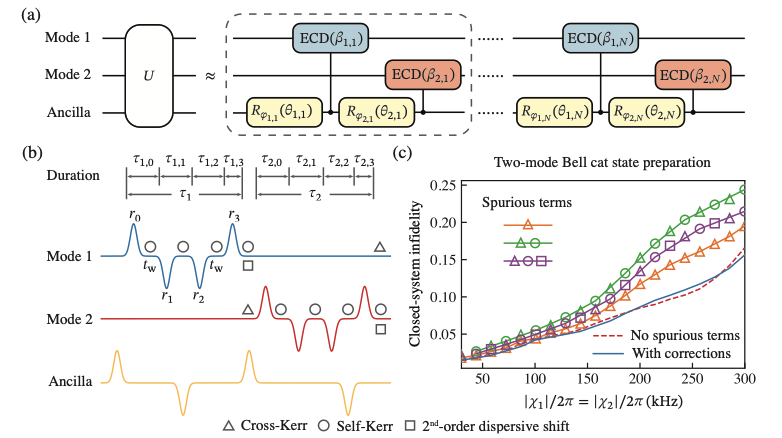

(Fig extracted from https://arxiv.org/pdf/2403.00275)

In [9]:
def Multimode_ECD_Compile(betas1_real,betas1_imag, betas2_real,betas2_imag, phis1, thetas1, phis2, thetas2,
                          Unitary, N_trunc, tol, Add_block = False, Disp = False, Mode='A'):

    '''Mode 'A'- cavity 1 
       Mode 'B' - cavity 2
       Mode 'AB' - cavities 1 and 2'''

    
       #   Transmon-Cavity1-Cavity2 
    def ECD1(beta_real, beta_imag, N_trunc):         
        return qt.tensor(qt.tensor(sigmap(), displace(N_trunc, (beta_real+ 1j*beta_imag)/2)) + 
                qt.tensor(sigmam(), displace(N_trunc, -(beta_real+ 1j*beta_imag)/2)), qt.qeye(N_trunc))

    def ECD2(beta_real, beta_imag, N_trunc):         
        return qt.tensor(qt.tensor(sigmap(), qt.qeye(N_trunc)), displace(N_trunc, (beta_real+ 1j*beta_imag)/2)
                        ) + qt.tensor(qt.tensor(sigmam(), qt.qeye(N_trunc)), displace(N_trunc, -(beta_real+ 1j*beta_imag)/2))
    
    # def Rot(phi, theta, N_trunc):
    #     return tensor(rz(phi) * rx(theta) * rz(-phi), qeye(N_trunc))
    
    def mRot(phi, theta, N_trunc):
        sx = qt.tensor(qt.tensor(qt.sigmax(), qt.qeye(N_trunc)), qt.qeye(N_trunc))
        sy = qt.tensor(qt.tensor(qt.sigmay(), qt.qeye(N_trunc)), qt.qeye(N_trunc))
        idty = qt.tensor(qt.tensor(qt.qeye(2), qt.qeye(N_trunc)), qt.qeye(N_trunc))
        if theta == 0:
            return idty
        else:          
            return ((np.cos(theta/2.0))*idty - 1j * ((np.cos(phi) * sx) + (np.sin(phi) * sy)) * np.sin(theta/2.0))
       
        # return (-1j*(theta/2.0)*(np.cos(phi)*self.sx + np.sin(phi)*self.sy)).expm()        
        # return np.cos(theta / 2.0) * idty - 1j * (
        #     np.cos(phi) * sx + np.sin(phi) * sy
        # ) * np.sin(theta / 2.0)
    
    
    # One ECD Block
    def U_block_ECD(beta1_real, beta1_imag, beta2_real, beta2_imag, phi1, theta1, phi2, theta2,  N_trunc):
        return  ECD2(beta2_real, beta2_imag,  N_trunc)*mRot(phi2, theta2, N_trunc)*ECD1(beta1_real, beta1_imag, 
                                                                                   N_trunc) * mRot(phi1, theta1, N_trunc) 

    # Sequence of ECD blocks
    def U_circuit_ECD(betas1_real, betas1_imag, betas2_real, betas2_imag, phis1, thetas1, phis2, thetas2, N_trunc):
        
        U = qt.tensor(qt.tensor(qt.identity(2), qt.identity(N_trunc)), qt.qeye(N_trunc))
        for beta1_real, beta1_imag, beta2_real, beta2_imag, phi1, theta1, phi2, theta2 in zip(betas1_real[:-1], 
                betas1_imag[:-1], betas2_real[:-1], betas2_imag[:-1], phis1[:-1], thetas1[:-1], phis2[:-1], thetas2[:-1]): # [:-1] removes the last element in the list since they are  Disp. and rotation parameter
            U = U_block_ECD(beta1_real, beta1_imag, beta2_real, beta2_imag, phi1, theta1, phi2, theta2,  N_trunc) * U
            # U = U_block_ECD2(beta_real, beta_imag, phi, theta, N_trunc) * U
        
        if Add_block == False:
            return U
        else:
            return qt.tensor(qt.tensor(qt.qeye(2), qt.qeye(N_trunc)),displace(N_trunc, (betas2_real[-1]+ 1j*
                    betas2_imag[-1])/2)) * mRot(phis2[-1], thetas2[-1], N_trunc)*qt.tensor(qt.tensor(qt.qeye(2), displace(N_trunc, 
                        (betas1_real[-1]+ 1j*betas1_imag[-1])/2)),qt.qeye(N_trunc)) * mRot(phis1[-1], thetas1[-1], N_trunc) * U
    
    def Unitary_cost(Oper1, Oper2):
              # tracedist(Oper1, Oper1)
            # cost = 1- (abs((Oper1.dag()*Oper2).tr()/Oper1.shape[0]))**2
            U1 = Qobj(Oper1[0:N_trunc**2, 0:N_trunc**2]- Oper2[0:N_trunc**2, 0:N_trunc**2], dims = [N_trunc**2, N_trunc**2])
            # U2 = Qobj(Oper1[N_trunc:2*N_trunc, N_trunc:2*N_trunc]- Oper2[N_trunc:2*N_trunc, N_trunc:2*N_trunc],dims = [N_trunc, N_trunc])      
            cost = np.sqrt((U1.dag()*U1).tr())        
            return cost                      
    
    opt_process = {}  
    def my_callback(result):
        """
        A callback function to monitor optimization progress.
        """
        val = Error_func(result, Unitary, N_trunc)
        opt_process[val]= result
    
    # Trace norm
    
    def Error_func(params, Unitary, N_trunc):
        '''params=[betas1_real, betas1_imag, betas2_real, betas2_imag, phis1, thetas1, phis2, thetas2] - hence 8l sized list '''
        ''''  args = (Unitary)'''
        
        r = int(len(params)/8)
        U = U_circuit_ECD(params[0:r], params[r:2*r], params[2*r:3*r], params[3*r:4*r], params[4*r:5*r], 
                          params[5*r:6*r], params[6*r:7*r], params[7*r:8*r],N_trunc)
        return Unitary_cost(Unitary, U)

    def grad(ini_params, Unitary, N_trunc):

        deriv = [] 
        epsilon = 5e-8
        for i in range(len(ini_params)):
            new_params_plus = [ele for ele in ini_params]
            new_params_minus = [ele for ele in ini_params] 
            new_params_plus[i] = ini_params[i] + epsilon
            new_params_minus[i] = ini_params[i] - epsilon
            partial_deriv_i = (Error_func(new_params_plus, Unitary, N_trunc) 
                               - Error_func(new_params_minus, Unitary, N_trunc))/(2*np.sinh(epsilon))
            deriv.append(partial_deriv_i)  
        return deriv

    def grad2(ini_params, Unitary, N_trunc):

        deriv = []
        h = 1e-8
        for i in range(len(ini_params)):            
            params_plus = [ele for ele in ini_params]
            params_plus[i] = params_plus[i] + h
            partial_deriv_i = (Error_func(params_plus, Unitary, N_trunc) 
                               - Error_func(ini_params, Unitary, N_trunc))/h
            deriv.append(partial_deriv_i)  
        return deriv


    if Mode == 'A':
        print('\n'+'*'*20 + ' Compiling for Unitary in Cavity 1 '+ '*'*20 )
        return  ECD_Compile(betas1_real,betas1_imag , phis1, thetas1, Unitary, N_trunc, tol, Add_block = Add_block, Disp = Disp)

    elif Mode == 'B':
         print('\n'+'*'*20 + ' Compiling for Unitary in Cavity 2 '+ '*'*20 )
         return ECD_Compile(betas2_real,betas2_imag , phis2, thetas2, Unitary, N_trunc, tol, Add_block = Add_block, Disp = Disp)

    
    else: 
        print('\n'+'*'*20 + ' Compiling for Unitary in Cavity 1 and 2 '+ '*'*20 )
        if Unitary.isunitary == False:
            raise ValueError("Provided operator is non-unitary.")
        
    
        
        if Add_block == True:
            Extra_block = 1
        else:
            Extra_block = 0        
            
        phis_thetas = np.concatenate((phis1, np.concatenate((thetas1, np.concatenate((phis2, thetas2))))))
        betasreal_betas_imag = np.concatenate((betas1_real, np.concatenate((betas1_imag, np.concatenate((betas2_real, betas2_imag))))))
        ini_params = np.concatenate((betasreal_betas_imag, phis_thetas))
        k = int(len(ini_params)/8)

        print('\n' + '*'* 20 + f' Optimizing Parameters for {k - 1 + Extra_block} blocks ' 
              + f'including {Extra_block} Disp_Rot block ' + '*'* 20 )
        res = minimize(Error_func, ini_params, args = (Unitary, N_trunc), method = 'L-BFGS-B',  jac = grad,
                       tol = tol, callback = my_callback)    # jac = grad,, options={'gtol': 1e-8, 'maxiter':1000}

        opt_arg = res.x
        opt_val = res.fun   
        opt_hist = list(opt_process.keys())
    
        out_dict = {'Infidelity': opt_val, 'Betas1_real': opt_arg[0:k], 'Betas1_imag': opt_arg[k:2*k], 'Betas2_real': opt_arg[2*k:3*k],
                    'Betas2_imag': opt_arg[3*k:4*k], 'Phis1': opt_arg[4*k:5*k], 'Thetas1': opt_arg[5*k:6*k], 'Phis2': opt_arg[6*k:7*k],
                    'Thetas2': opt_arg[7*k:8*k]}    
        


        # Plot optimization History
        if Disp==True:
            plt.plot(range(len(opt_hist)), opt_hist, marker='o', linestyle='dashed')
            plt.axhline(y = opt_val, color = 'r', linestyle='--', label= f'y = {opt_val:.3g}')
            plt.title(f'Optimization History for {k} blocks with {Extra_block} Disp_Rot block.')
            plt.grid(which = 'both', axis='both')
            plt.ylabel('Infidelity')
            plt.xlabel('Number of shots')
            plt.yscale('log')
            plt.legend()
            plt.show()
            plt.savefig('Multimode', format= 'pdf')
            Mat = U_circuit_ECD(opt_arg[0:k],opt_arg[k:2*k], opt_arg[2*k:3*k], opt_arg[3*k:4*k],  opt_arg[4*k:5*k], opt_arg[5*k:6*k], opt_arg[6*k:7*k],
                          opt_arg[7*k:8*k],N_trunc)
            
        return out_dict, Mat

In [11]:
np.random.seed(10)
length = 6

# ECD sequence length (+1 since an extra block is used for unconditional displacement + Rotation)
N_blocks = length +1 

N_trunc = 2
betas1_real= np.random.randn(N_blocks) 
betas1_imag= np.random.randn(N_blocks)
betas2_real= np.random.randn(N_blocks) 
betas2_imag= np.random.randn(N_blocks)
phis1 =  np.random.randn(N_blocks)
thetas1 = 2*np.pi*np.random.randn(N_blocks)
phis2 =  np.random.randn(N_blocks)
thetas2 = 2*np.pi*np.random.randn(N_blocks)
tol = 1e-12 

In [12]:
# Define cavity unitary
mat = np.zeros((N_trunc, N_trunc), dtype = np.complex64)
mat[0,1]= 1
mat[1,0] = 1
mcav_unitary1 = Qobj(mat, dims = [N_trunc, N_trunc])

mat2 = np.zeros((N_trunc, N_trunc), dtype = np.complex64)
for k in range(N_trunc):
    mat2[k,k] = np.exp(1j*np.pi*(k+1)/2)
mcav_unitary2 = Qobj(mat2, dims = [N_trunc, N_trunc])

# generate random cavity unitary
# mcav_unitary1 = Qobj(unitary_group.rvs(N_trunc), dims = [N_trunc, N_trunc]) 
# mcav_unitary2 = qt.qeye(N_trunc)       #Qobj(unitary_group.rvs(N_trunc), dims = [N_trunc, N_trunc])  

# generate random Transmon unitary
trans_unitary = Qobj(unitary_group.rvs(2), dims = [2, 2])      
# mUnitary = qt.tensor(qt.tensor(trans_unitary, mcav_unitary1), mcav_unitary2)
mUnitary = qt.tensor(qt.tensor(qt.qeye(2), mcav_unitary1), mcav_unitary2)


# generate random full unitary for 2-mode
twoMode_unitary = Qobj(unitary_group.rvs(N_trunc**2), dims = [[N_trunc, N_trunc], [N_trunc, N_trunc]]) 
mUnitary2 = qt.tensor(qt.qeye(2), twoMode_unitary)
   


******************** Compiling for Unitary in Cavity 1 and 2 ********************

******************** Optimizing Parameters for 6 blocks including 0 Disp_Rot block ********************


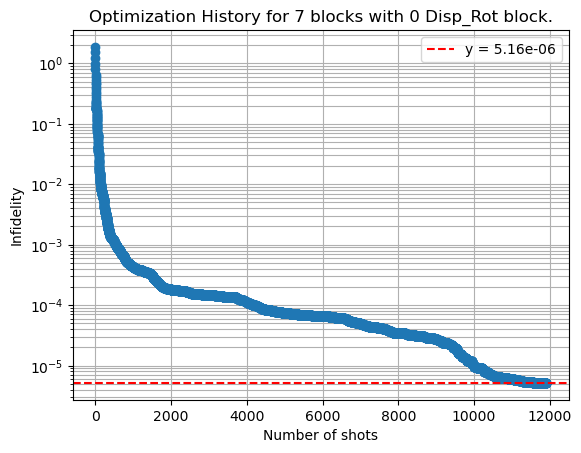

CPU times: user 14h 33min 6s, sys: 42.7 s, total: 14h 33min 48s
Wall time: 6h 3min 15s


({'Infidelity': 5.155357543198787e-06,
  'Betas1_real': array([ 2.25167658e+00,  1.38689111e+00, -2.06802541e+00,  7.45668568e-01,
         -1.43961911e-03, -1.19053869e+00,  2.65511586e-01]),
  'Betas1_imag': array([2.26694107, 0.91296596, 0.38312786, 1.12635916, 0.28671597,
         0.93207943, 1.02827408]),
  'Betas2_real': array([ 1.01174497,  0.02781672, -0.89821289, -0.11091609,  2.3571348 ,
         -0.23127907, -1.97772828]),
  'Betas2_imag': array([-1.82876078,  0.61187915,  2.06108364,  1.06575973,  1.25612113,
          0.91948551,  1.39799638]),
  'Phis1': array([-1.43979685,  0.61101084,  0.7345367 , -0.61908248, -0.23606305,
          0.88751351,  1.30847308]),
  'Thetas1': array([ 2.51896917,  1.57500446, -1.50990765,  7.25074803, -4.71204969,
          4.84957206, -2.20459311]),
  'Phis2': array([ 0.16208122,  0.0324451 , -1.85266168,  0.90283485, -0.86977402,
         -0.0917314 ,  0.56515267]),
  'Thetas2': array([-0.76157855, -0.22385398,  1.1882511 , -3.96986209,  4

<Figure size 640x480 with 0 Axes>

In [13]:
%time Multimode_ECD_Compile(betas1_real,betas1_imag, betas2_real,betas2_imag, phis1, thetas1, phis2, thetas2, mUnitary2, N_trunc, tol, Add_block = False, Disp=True, Mode='AB')

In [14]:
mUnitary2

Quantum object: dims=[[2, 2, 2], [2, 2, 2]], shape=(8, 8), type='oper', dtype=Dia, isherm=False
Qobj data =
[[-0.03192817+0.78129208j  0.12915672+0.32877894j  0.16135681-0.46984638j
   0.10804122-0.07294988j  0.        +0.j          0.        +0.j
   0.        +0.j          0.        +0.j        ]
 [-0.14267288-0.02591648j -0.00943488-0.56845438j  0.00100666-0.55981012j
  -0.17198519+0.55926388j  0.        +0.j          0.        +0.j
   0.        +0.j          0.        +0.j        ]
 [-0.08493086+0.08551149j  0.34156594-0.57632946j  0.20102605+0.099229j
   0.62667305-0.30606309j  0.        +0.j          0.        +0.j
   0.        +0.j          0.        +0.j        ]
 [-0.59364706-0.02436741j  0.32116254-0.00502265j -0.61234881-0.1207934j
  -0.20488953-0.33507755j  0.        +0.j          0.        +0.j
   0.        +0.j          0.        +0.j        ]
 [ 0.        +0.j          0.        +0.j          0.        +0.j
   0.        +0.j         -0.03192817+0.78129208j  0.12915672+0.3